In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from argparse import ArgumentParser
from tqdm import trange

sys.path.append(os.getcwd()+"/..")

# Placeholder for your custom functions
from simulation.utils import (
    generate_unit_cell_anisotropy, 
    lattice_parameters_reciprocal,
    reciprocal_lattice_vectors, 
    random_rotate_vectors,
    generate_reciprocal_lattice,
    fibonacci_orientations,
    orientations_to_indices,
    align_reciprocal_lattice,
    simulate_diffraction_experiment,
    project_reflections_2D,
    remove_random_pairs,
    add_random_pairs,
    add_noise,
    shift_points,
    save_parameters,
    is_linear_combination,
    find_linear_independent
)


Generated unit cell parameters:
a = 7.454 Å
b = 7.522 Å
c = 10.586 Å
alpha = 116.92°
beta = 107.53°
gamma = 93.98°
Reciprocal lattice parameters:
astar = 0.200
bstar = 0.167
cstar = 0.143
alphastar = 90.000°
betastar = 90.000°
gammastar = 90.000°
True


In [7]:
# Notebook defaults (no CLI input)
target_volume = 500
volume_error = 100
a_range = [3.5, 15]
b_range = [4, 30]
c_range = [5, 45]
alpha_range = [90, 120]
beta_range = [90, 120]
gamma_range = [90, 120]
anisotropy = 1.5
resolution = 0.85
wavelength = 0.0407
excitation_error = 0.015
detector_distance = 0
edge = 1.5
fraction_limit_missing = 0.03
fraction_limit_additional = 0.05
noise_level = 0.0012
max_shift = 0.01
N = 1000
zonal_sample_threshold = 0.9
zonal_segmentation_threshold = 0.4
output_folder = "output"

# Generate unit cell parameters
a, b, c, alpha, beta, gamma = generate_unit_cell_anisotropy(
    target_volume, a_range, b_range, c_range, alpha_range, beta_range, gamma_range, volume_error, anisotropy
)

# Round the parameters
a = round(a, 3)
b = round(b, 3)
c = round(c, 3)
alpha = round(alpha, 2)
beta = round(beta, 2)
gamma = round(gamma, 2)

# Display results
print(f"Generated unit cell parameters:")
print(f"a = {a:.3f} Å")
print(f"b = {b:.3f} Å")
print(f"c = {c:.3f} Å")
print(f"alpha = {alpha:.2f}°")
print(f"beta = {beta:.2f}°")
print(f"gamma = {gamma:.2f}°")


# Compute reciprocal lattice parameters
astar, bstar, cstar, alphastar, betastar, gammastar = lattice_parameters_reciprocal(a, b, c, alpha, beta, gamma)
v1, v2, v3 = reciprocal_lattice_vectors(astar, bstar, cstar, alphastar, betastar, gammastar)

astar_rot, bstar_rot, cstar_rot = random_rotate_vectors(v1, v2, v3)

# Generate reciprocal lattice reflections
hkl_list, reflections = generate_reciprocal_lattice(v1, v2, v3, resolution)

orientations = fibonacci_orientations(N)
indices = orientations_to_indices(orientations, astar_rot, bstar_rot, cstar_rot)
# Parameters
R = 1 / wavelength

# Compute Ewald sphere
theta, phi = np.meshgrid(np.linspace(0, np.pi, 50), np.linspace(0, 2 * np.pi, 100))
X = R * np.sin(theta) * np.cos(phi)
Y = R * np.sin(theta) * np.sin(phi)
Z = R * np.cos(theta)

# Shift the sphere to the Ewald center
X = X + 0
Y = Y + 0
Z = Z + R

zonal_list = []
segmentation_list = []


Generated unit cell parameters:
a = 8.791 Å
b = 8.564 Å
c = 7.512 Å
alpha = 103.33°
beta = 113.01°
gamma = 99.80°


In [8]:
i = 0
rotated_reflections = align_reciprocal_lattice(reflections, orientations[i, :])
ewald_sphere, diffraction_spots, hkl_included = simulate_diffraction_experiment(hkl_list, rotated_reflections, wavelength, excitation_error)

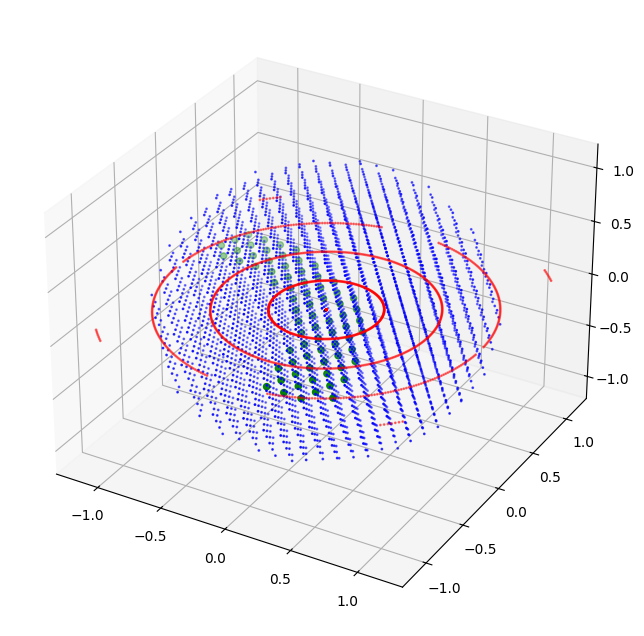

In [31]:
import matplotlib.pyplot as plt

reflection_bounds = np.concatenate([np.min(reflections, axis=0), np.max(reflections, axis=0)])
ewald_sphere_viz = ewald_sphere[(ewald_sphere[:, 0] >= reflection_bounds[0]) & (ewald_sphere[:, 0] <= reflection_bounds[3]) &
                             (ewald_sphere[:, 1] >= reflection_bounds[1]) & (ewald_sphere[:, 1] <= reflection_bounds[4]) &
                             (ewald_sphere[:, 2] >= reflection_bounds[2]) & (ewald_sphere[:, 2] <= reflection_bounds[5])]

ax = plt.figure(figsize=(8, 8)).add_subplot(111, projection='3d')
ax.scatter(reflections[:, 0], reflections[:, 1], reflections[:, 2], color='blue', label='Reflections', s=1)
ax.scatter(ewald_sphere_viz[:, 0], ewald_sphere_viz[:, 1], ewald_sphere_viz[:, 2], color='red', label='Ewald Sphere', s=1, alpha=0.5)
ax.scatter(diffraction_spots[:, 0], diffraction_spots[:, 1], diffraction_spots[:, 2], color='green', label='Diffraction Spots', s=20)

In [85]:
import open3d as o3d

ewald_sphere_pc = o3d.geometry.PointCloud()
ewald_sphere_pc.points = o3d.utility.Vector3dVector(ewald_sphere_viz)
ewald_sphere_pc.paint_uniform_color([1, 0, 0])  # Red for Ewald sphere

rotated_reflections_pc = o3d.geometry.PointCloud()
rotated_reflections_pc.points = o3d.utility.Vector3dVector(rotated_reflections)
rotated_reflections_pc.paint_uniform_color([0, 0, 1])  # Blue for reflections

diffraction_spots_pc = o3d.geometry.PointCloud()
diffraction_spots_pc.points = o3d.utility.Vector3dVector(diffraction_spots)
diffraction_spots_pc.paint_uniform_color([0, 1, 0])  # Green for diffraction spots


camera_direction = orientations[i, :]
camera_position = camera_direction * 1/wavelength
center = np.array([0.0, 0.0, 0.0])
dir_vec = center - camera_position
dir_unit = dir_vec / np.linalg.norm(dir_vec)

z_axis = np.array([0.0, 0.0, 1.0])
v = np.cross(z_axis, dir_unit)
s = np.linalg.norm(v)
c = np.dot(z_axis, dir_unit)
if s < 1e-8:
    R = np.eye(3) if c > 0 else np.diag([1.0, -1.0, -1.0])
else:
    K = np.array([[0.0, -v[2], v[1]], [v[2], 0.0, -v[0]], [-v[1], v[0], 0.0]])
    R = np.eye(3) + K + K @ K * ((1.0 - c) / (s**2))

cam_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)
T = np.eye(4)
T[:3, :3] = R
T[:3, 3] = camera_position
cam_frame.transform(T)
cam_frame.paint_uniform_color([0.8, 0.2, 0.2])

o3d.visualization.draw_geometries([ewald_sphere_pc, rotated_reflections_pc, diffraction_spots_pc, cam_frame], window_name='3D Visualization', width=800, height=600)


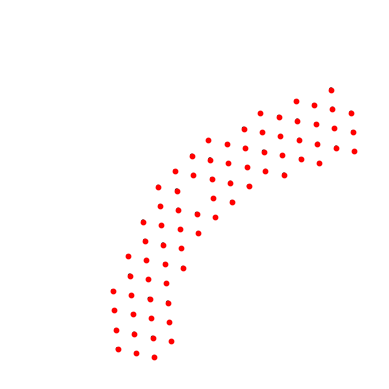

In [146]:
import cv2 

canvas_size = 1000
focal_length = canvas_size * 10
K_intrinsic = np.array([[focal_length, 0, canvas_size // 2], [0, focal_length, canvas_size // 2], [0, 0, 1]])
T_extrinsics = np.linalg.inv(T)

world_pts_homogeneous = np.hstack([diffraction_spots, np.ones((diffraction_spots.shape[0], 1))])
projected_pts_homogeneous = ((K_intrinsic @ T_extrinsics[:3, :]) @ world_pts_homogeneous.T).T
projected_x = projected_pts_homogeneous[:, 0] / projected_pts_homogeneous[:, 2]
projected_y = projected_pts_homogeneous[:, 1] / projected_pts_homogeneous[:, 2]
depth = projected_pts_homogeneous[:, 2]


canvas = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255
depth_map = np.full((canvas_size, canvas_size), np.inf)

meshgrid_x, meshgrid_y = np.meshgrid(np.arange(canvas_size), np.arange(canvas_size))
meshgrid_points = np.stack([meshgrid_x, meshgrid_y], axis=-1).reshape(-1, 2)
for x, y, d in zip(projected_x, projected_y, depth):
    if 0 <= x < canvas.shape[1] and 0 <= y < canvas.shape[0]:
        circle_radius = 5
        circle_center = np.array([x, y], dtype=np.int32)
        canvas[(meshgrid_x - circle_center[0]) ** 2 + (meshgrid_y - circle_center[1]) ** 2 < circle_radius ** 2] = 0
        depth_map[(meshgrid_x - circle_center[0]) ** 2 + (meshgrid_y - circle_center[1]) ** 2 < circle_radius ** 2] = d
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.scatter(projected_x, projected_y, color='red', s=10)


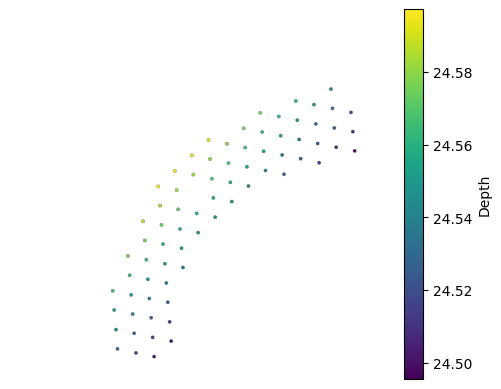

In [ ]:
plt.imshow(depth_map, cmap='viridis')
plt.colorbar(label='Depth')
plt.axis('off')
plt.show()

In [ ]:
import json

os.makedirs("output/images", exist_ok=True)
os.makedirs("output/depth_maps", exist_ok=True)


canvas_size = 1000
focal_length = canvas_size * 10
K_intrinsic = np.array([[focal_length, 0, canvas_size // 2], [0, focal_length, canvas_size // 2], [0, 0, 1]])
meshgrid_x, meshgrid_y = np.meshgrid(np.arange(canvas_size), np.arange(canvas_size))

extrinsics = []

for i in range(200):
    rotated_reflections = align_reciprocal_lattice(reflections, orientations[i, :])
    ewald_sphere, diffraction_spots, hkl_included = simulate_diffraction_experiment(hkl_list, rotated_reflections, wavelength, excitation_error)
    
    camera_direction = orientations[i, :]
    camera_position = camera_direction * 1/wavelength
    center = np.array([0.0, 0.0, 0.0])
    dir_vec = center - camera_position
    dir_unit = dir_vec / np.linalg.norm(dir_vec)

    z_axis = np.array([0.0, 0.0, 1.0])
    v = np.cross(z_axis, dir_unit)
    s = np.linalg.norm(v)
    c = np.dot(z_axis, dir_unit)
    if s < 1e-8:
        R = np.eye(3) if c > 0 else np.diag([1.0, -1.0, -1.0])
    else:
        K = np.array([[0.0, -v[2], v[1]], [v[2], 0.0, -v[0]], [-v[1], v[0], 0.0]])
        R = np.eye(3) + K + K @ K * ((1.0 - c) / (s**2))

    T_world_to_camera = np.eye(4)
    T_world_to_camera[:3, :3] = R
    T_world_to_camera[:3, 3] = camera_position

    T_extrinsics = np.linalg.inv(T_world_to_camera)

    world_pts_homogeneous = np.hstack([diffraction_spots, np.ones((diffraction_spots.shape[0], 1))])
    projected_pts_homogeneous = ((K_intrinsic @ T_extrinsics[:3, :]) @ world_pts_homogeneous.T).T
    projected_x = projected_pts_homogeneous[:, 0] / projected_pts_homogeneous[:, 2]
    projected_y = projected_pts_homogeneous[:, 1] / projected_pts_homogeneous[:, 2]
    depth = projected_pts_homogeneous[:, 2]


    canvas = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255
    depth_map = np.full((canvas_size, canvas_size), np.inf, dtype=np.float16)
    depth_mask = np.zeros((canvas_size, canvas_size), dtype=bool)

    for x, y, d in zip(projected_x, projected_y, depth):
        if 0 <= x < canvas.shape[1] and 0 <= y < canvas.shape[0]:
            circle_radius = 5
            circle_center = np.array([x, y], dtype=np.int32)
            canvas[(meshgrid_x - circle_center[0]) ** 2 + (meshgrid_y - circle_center[1]) ** 2 < circle_radius ** 2] = 0
            depth_map[(meshgrid_x - circle_center[0]) ** 2 + (meshgrid_y - circle_center[1]) ** 2 < circle_radius ** 2] = d
            depth_mask[(meshgrid_x - circle_center[0]) ** 2 + (meshgrid_y - circle_center[1]) ** 2 < circle_radius ** 2] = True


    cv2.imwrite(f"output/images/diffraction_pattern_{i:03d}.png", canvas)
    np.save(f"output/depth_maps/depth_map_{i:03d}.npy", depth_map)
    cv2.imwrite(f"output/images/depth_mask_{i:03d}.png", (depth_mask.astype(np.uint8) * 255))
    extrinsics.append(T_extrinsics.tolist())

with open(os.path.join(output_folder, "extrinsics.json"), "w") as f:
    json.dump(extrinsics, f, indent=4)
with open(os.path.join(output_folder, "intrinsics.json"), "w") as f:
    json.dump(K_intrinsic.tolist(), f, indent=4)